定义问题规模，随机生成矩阵，
使用遗传算法和模拟退火算法进行计算
得到一次运行结果，与5次运行结果

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
import base64
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   # 新增

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

class Config:
    # ========== 问题规模 ==========这里可以随便改
    SPOT_NUM = 7          # 图斑数量（原4，可增加到10、20等）
    PROCESS_NUM = 5        # 每个图斑的工序数（原3）
    WORKER_NUM = 6         # 工人数量（原2）
    DEVICE_NUM = 7         # 每个工人的设备数量（原4）
    DATA_SEED = 42           # 数据生成随机种子（固定，不随算法调用改变）
    
    # ========== 遗传算法参数 ==========
    POPULATION_SIZE = 150
    MAX_ITERATIONS = 200
    CROSSOVER_RATE = 0.8
    MUTATION_RATE = 0.15
    ELITE_RATIO = 0.1
    SEED = 45
    
    # ========== 派生属性 ==========
    @property
    def RESOURCE_NUM(self):
        return self.WORKER_NUM * self.DEVICE_NUM
    
    @property
    def TOTAL_OPERATIONS(self):
        return self.SPOT_NUM * self.PROCESS_NUM
        
def init_data(config=None):
    if config is None:
        config = Config()
    
    spot_num = config.SPOT_NUM
    proc_num = config.PROCESS_NUM
    worker_num = config.WORKER_NUM
    device_num = config.DEVICE_NUM
    total_ops = spot_num * proc_num
    res_num = worker_num * device_num
    
    # 加工时间矩阵
    np.random.seed(config.DATA_SEED)
    process_time = np.random.randint(3, 20, size=(total_ops, res_num)).astype(float)
    for w in range(worker_num):
        for d in range(device_num):
            res_idx = w * device_num + d
            process_time[:, res_idx] *= np.random.uniform(0.7, 1.0)
    process_time = np.clip(process_time, 1, None)
    
    # 转移时间矩阵
    np.random.seed(config.DATA_SEED + 1)
    coords = np.random.rand(spot_num, 2) * 100
    transfer_time = np.zeros((spot_num, spot_num))
    for i in range(spot_num):
        for j in range(spot_num):
            dist = np.linalg.norm(coords[i] - coords[j])
            transfer_time[i][j] = dist / 30
    np.fill_diagonal(transfer_time, 0)
    
    # 重叠比率矩阵
    np.random.seed(config.DATA_SEED + 2)
    overlap_ratio = np.random.rand(spot_num, spot_num) * 0.3
    overlap_ratio = (overlap_ratio + overlap_ratio.T) / 2
    np.fill_diagonal(overlap_ratio, 0)
    
    # 冲突矩阵（确定性，无需随机）
    conflict_matrix = np.zeros((res_num, res_num), dtype=int)
    for w in range(worker_num):
        start = w * device_num
        for i in range(start, start + device_num):
            for j in range(start, start + device_num):
                if i != j:
                    conflict_matrix[i][j] = 1
    for d in range(device_num):
        indices = [w * device_num + d for w in range(worker_num)]
        for i in indices:
            for j in indices:
                if i != j:
                    conflict_matrix[i][j] = 1
    
    return process_time, transfer_time, overlap_ratio, conflict_matrix

# 四种算法

In [2]:
class TraditionalGA:
    def __init__(self, config: Config, process_time: np.ndarray, conflict_matrix: np.ndarray, seed=None):
        self.config = config
        #self.config.MUTATION_RATE = 0.6
        self.process_time = process_time
        self.conflict_matrix = conflict_matrix
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)

    def create_individual(self):
        g1 = random.sample(range(self.config.SPOT_NUM), self.config.SPOT_NUM)
        g2 = [random.randint(0, self.config.RESOURCE_NUM-1) 
              for _ in range(self.config.TOTAL_OPERATIONS)]
        return g1 + g2

    def init_population(self):
        return [self.create_individual() for _ in range(self.config.POPULATION_SIZE)]

    def _simulate(self, individual, return_schedule=False):
        """通用调度模拟，可选择返回调度信息"""
        n = self.config.SPOT_NUM
        p = self.config.PROCESS_NUM
        g1 = individual[:n]
        g2 = individual[n:]

        resource_free = [0.0] * self.config.RESOURCE_NUM
        job_finish = np.zeros((n, p))
        current_op = [0] * n
        schedule = [] if return_schedule else None

        # 初始化：按g1顺序启动第一道工序
        for spot in g1:
            op_idx = spot * p
            res = g2[op_idx]
            conflict_res = np.where(self.conflict_matrix[res] == 1)[0].tolist()
            all_res = [res] + conflict_res
            max_free = max(resource_free[r] for r in all_res)
            start_time = max_free
            proc_time = self.process_time[op_idx][res]
            finish_time = start_time + proc_time
            job_finish[spot][0] = finish_time
            for r in all_res:
                resource_free[r] = finish_time
            if return_schedule:
                schedule.append((spot, 0, res, start_time, finish_time))

        # 事件驱动
        events = [(job_finish[spot][0], spot, 0) for spot in g1]
        events.sort()
        while events:
            finish, spot, proc = events.pop(0)
            current_op[spot] = proc + 1
            next_proc = proc + 1
            if next_proc < p:
                op_idx = spot * p + next_proc
                res = g2[op_idx]
                conflict_res = np.where(self.conflict_matrix[res] == 1)[0].tolist()
                all_res = [res] + conflict_res
                max_free = max(resource_free[r] for r in all_res)
                start_time = max(job_finish[spot][proc], max_free)
                proc_time = self.process_time[op_idx][res]
                finish_time = start_time + proc_time
                job_finish[spot][next_proc] = finish_time
                for r in all_res:
                    resource_free[r] = finish_time
                events.append((finish_time, spot, next_proc))
                events.sort()
                if return_schedule:
                    schedule.append((spot, next_proc, res, start_time, finish_time))

        makespan = np.max(job_finish)
        if return_schedule:
            return makespan, schedule
        return makespan

    def decode(self, individual):
        return self._simulate(individual, return_schedule=False)

    def get_schedule(self, individual):
        """返回调度信息列表，每个元素 (spot, process, resource, start, end)"""
        _, schedule = self._simulate(individual, return_schedule=True)
        return schedule

    def calculate_fitness(self, individual):
        makespan = self.decode(individual)
        return 1.0 / makespan if makespan > 0 else 1e-6

    def selection(self, population, fitness):
        total_fit = sum(fitness)
        if total_fit == 0:
            return random.choice(population)
        prob = [f/total_fit for f in fitness]
        r = random.random()
        cum = 0.0
        for i, p in enumerate(prob):
            cum += p
            if r <= cum:
                return population[i]
        return population[-1]

    def crossover(self, p1, p2):
        if random.random() > self.config.CROSSOVER_RATE:
            return p1.copy()
        n = self.config.SPOT_NUM
        g1_p1 = p1[:n]
        g1_p2 = p2[:n]
        g2_p1 = p1[n:]
        g2_p2 = p2[n:]

        # OX交叉 for g1
        size = n
        a, b = sorted(random.sample(range(size), 2))
        child_g1 = [-1] * size
        child_g1[a:b+1] = g1_p1[a:b+1]
        pos = (b + 1) % size
        for i in range(size):
            idx = (b + 1 + i) % size
            item = g1_p2[idx]
            if item not in child_g1:
                child_g1[pos] = item
                pos = (pos + 1) % size

        # 两点交叉 for g2
        length = len(g2_p1)
        point1, point2 = sorted(random.sample(range(length), 2))
        child_g2 = g2_p1[:point1] + g2_p2[point1:point2] + g2_p1[point2:]

        return child_g1 + child_g2

    def mutate(self, individual):
        n = self.config.SPOT_NUM
        g1 = individual[:n]
        g2 = individual[n:]
        # g1变异：交换
        if random.random() < self.config.MUTATION_RATE:
            i, j = random.sample(range(n), 2)
            g1[i], g1[j] = g1[j], g1[i]
        # g2变异
        for i in range(len(g2)):
            if random.random() < self.config.MUTATION_RATE:
                g2[i] = random.randint(0, self.config.RESOURCE_NUM-1)
        return g1 + g2

    def run(self):
        population = self.init_population()
        best_individual = None
        best_makespan = float('inf')
        history = []

        for gen in range(self.config.MAX_ITERATIONS):
            fitness = [self.calculate_fitness(ind) for ind in population]
            best_idx = np.argmax(fitness)
            current_makespan = 1.0 / fitness[best_idx]
            if current_makespan < best_makespan:
                best_makespan = current_makespan
                best_individual = population[best_idx].copy()
            history.append(best_makespan)

            new_population = []
            for _ in range(self.config.POPULATION_SIZE):
                p1 = self.selection(population, fitness)
                p2 = self.selection(population, fitness)
                child = self.crossover(p1, p2)
                child = self.mutate(child)
                new_population.append(child)
            population = new_population

            if (gen+1) % 20 == 0:
                print(f"传统GA - 迭代{gen+1} | 最优工期：{best_makespan:.2f}h")

        return best_individual, best_makespan, history

# ====================== 4. 改进型遗传算法 ======================
class ImprovedGA:
    def __init__(self, config: Config, process_time: np.ndarray, conflict_matrix: np.ndarray,
                 transfer_time: np.ndarray, overlap_ratio: np.ndarray, seed=None):
        self.config = config
        self.process_time = process_time
        self.conflict_matrix = conflict_matrix
        self.transfer_time = transfer_time
        self.overlap_ratio = overlap_ratio
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)
        self.avg_process_time = np.mean(process_time, axis=1)

    def _resource_selection_prob(self, op_idx):
        times = self.process_time[op_idx]
        avg = self.avg_process_time[op_idx]
        epsilon = 0.1
        weights = np.where(times > avg, 1.0/(times - avg + epsilon), 1.0)
        probs = weights / np.sum(weights)
        return probs

    def create_individual(self):
        n = self.config.SPOT_NUM
        p = self.config.PROCESS_NUM
        g1 = []
        for _ in range(p):
            perm = random.sample(range(n), n)
            g1.extend(perm)
        g2 = []
        for op_idx in range(self.config.TOTAL_OPERATIONS):
            probs = self._resource_selection_prob(op_idx)
            res = np.random.choice(self.config.RESOURCE_NUM, p=probs)
            g2.append(res)
        return g1 + g2

    def init_population(self):
        return [self.create_individual() for _ in range(self.config.POPULATION_SIZE)]

    def _simulate(self, individual, return_schedule=False):
        n = self.config.SPOT_NUM
        p = self.config.PROCESS_NUM
        g1 = individual[:n*p]
        g2 = individual[n*p:]
    
        # 拆分每道工序的顺序
        proc_orders = [g1[i*n:(i+1)*n] for i in range(p)]
    
        resource_free = [0.0] * self.config.RESOURCE_NUM
        resource_last_spot = [-1] * self.config.RESOURCE_NUM
        job_finish = np.zeros((n, p))
        completed_ops = [0] * n
        # 记录每个图斑当前正在进行的工序的时间区间 (start, end)，None 表示空闲
        active_interval = [None] * n
        schedule = [] if return_schedule else None
        events = []
    
        # 启动第一道工序
        for spot in proc_orders[0]:
            op_idx = spot * p + 0
            res = g2[op_idx]
            conflict_res = np.where(self.conflict_matrix[res] == 1)[0].tolist()
            all_res = [res] + conflict_res
            max_free = max(resource_free[r] for r in all_res)
            base_time = self.process_time[op_idx][res]
            travel_time = 0 if resource_last_spot[res] == -1 else self.transfer_time[resource_last_spot[res]][spot]
            start_time = max(max_free, travel_time)

            # 计算重叠惩罚（迭代直到稳定）
            penalty = 0.0
            end_time = start_time + base_time
            max_iter = 5  # 防止无限循环
            for _ in range(max_iter):
                # 找出所有与该工序时间区间重叠的其他图斑的活跃工序
                overlapping_spots = []
                for s in range(n):
                    if s == spot or active_interval[s] is None:
                        continue
                    s_start, s_end = active_interval[s]
                    # 判断区间重叠
                    if max(start_time, s_start) < min(end_time, s_end):
                        overlapping_spots.append(s)
                # 计算总惩罚（基于当前 end_time 计算重叠，但惩罚因子使用 base_time）
                new_penalty = sum(self.overlap_ratio[spot][s] * base_time for s in overlapping_spots)
                if new_penalty == penalty:
                    break
                penalty = new_penalty
                end_time = start_time + base_time + penalty
            # 最终结束时间
            finish_time = end_time

            #print(f"Spot {spot}, res {res}, start_time = {start_time}, finish_time = {finish_time}")
            #print(f"  resource_free: {resource_free}")
            job_finish[spot][0] = finish_time
            active_interval[spot] = (start_time, finish_time)
            for r in all_res:
                resource_free[r] = finish_time
                resource_last_spot[r] = spot
            events.append((finish_time, spot, 0))
            if return_schedule:
                schedule.append((spot, 0, res, start_time, finish_time))
    
        events.sort()
        while events:
            finish, spot, proc = events.pop(0)
            # 当前工序已完成，清除活跃区间
            active_interval[spot] = None
            completed_ops[spot] = proc + 1
            next_proc = proc + 1
            if next_proc < p:
                op_idx = spot * p + next_proc
                res = g2[op_idx]
                conflict_res = np.where(self.conflict_matrix[res] == 1)[0].tolist()
                all_res = [res] + conflict_res
                max_free = max(resource_free[r] for r in all_res)
                base_time = self.process_time[op_idx][res]
                travel_time = 0 if resource_last_spot[res] == -1 else self.transfer_time[resource_last_spot[res]][spot]
                start_time = max(job_finish[spot][proc], max_free, travel_time)
    
                # 计算重叠惩罚（迭代）
                penalty = 0.0
                end_time = start_time + base_time
                for _ in range(5):
                    overlapping_spots = []
                    for s in range(n):
                        if s == spot or active_interval[s] is None:
                            continue
                        s_start, s_end = active_interval[s]
                        if max(start_time, s_start) < min(end_time, s_end):
                            overlapping_spots.append(s)
                    new_penalty = sum(self.overlap_ratio[spot][s] * base_time for s in overlapping_spots)
                    if new_penalty == penalty:
                        break
                    penalty = new_penalty
                    end_time = start_time + base_time + penalty
                finish_time = end_time
    
                job_finish[spot][next_proc] = finish_time
                active_interval[spot] = (start_time, finish_time)
                for r in all_res:
                    resource_free[r] = finish_time
                    resource_last_spot[r] = spot
                events.append((finish_time, spot, next_proc))
                events.sort()
                if return_schedule:
                    schedule.append((spot, next_proc, res, start_time, finish_time))
    
        makespan = np.max(job_finish)
        if return_schedule:
            return makespan, schedule
        return makespan

    def decode(self, individual):
        return self._simulate(individual, return_schedule=False)

    def get_schedule(self, individual):
        _, schedule = self._simulate(individual, return_schedule=True)
        return schedule

    def calculate_fitness(self, individual):
        makespan = self.decode(individual)
        return 1.0 / makespan if makespan > 0 else 1e-6

    def selection(self, population, fitness):
        tournament_size = 3
        selected = random.sample(list(zip(population, fitness)), tournament_size)
        selected.sort(key=lambda x: x[1], reverse=True)
        return selected[0][0]

    def crossover(self, p1, p2):
        if random.random() > self.config.CROSSOVER_RATE:
            return p1.copy()
        n = self.config.SPOT_NUM
        p = self.config.PROCESS_NUM
        g1_p1 = p1[:n*p]
        g1_p2 = p2[:n*p]
        g2_p1 = p1[n*p:]
        g2_p2 = p2[n*p:]

        child_g1 = []
        for proc in range(p):
            start = proc * n
            seg1 = g1_p1[start:start+n]
            seg2 = g1_p2[start:start+n]
            a, b = sorted(random.sample(range(n), 2))
            child_seg = [-1] * n
            child_seg[a:b+1] = seg1[a:b+1]
            pos = (b + 1) % n
            for i in range(n):
                idx = (b + 1 + i) % n
                item = seg2[idx]
                if item not in child_seg:
                    child_seg[pos] = item
                    pos = (pos + 1) % n
            child_g1.extend(child_seg)

        length = len(g2_p1)
        point1, point2 = sorted(random.sample(range(length), 2))
        child_g2 = g2_p1[:point1] + g2_p2[point1:point2] + g2_p1[point2:]
        return child_g1 + child_g2

    def mutate(self, individual):
        n = self.config.SPOT_NUM
        p = self.config.PROCESS_NUM
        g1 = individual[:n*p]
        g2 = individual[n*p:]

        for proc in range(p):
            if random.random() < self.config.MUTATION_RATE:
                start = proc * n
                seg = g1[start:start+n]
                i, j = random.sample(range(n), 2)
                seg[i], seg[j] = seg[j], seg[i]
                g1[start:start+n] = seg

        for i in range(len(g2)):
            if random.random() < self.config.MUTATION_RATE:
                probs = self._resource_selection_prob(i)
                g2[i] = np.random.choice(self.config.RESOURCE_NUM, p=probs)

        return g1 + g2

    def run(self):
        print(f"Random test: random={random.random()}, np={np.random.rand()}")
        population = self.init_population()
        best_individual = None
        best_makespan = float('inf')
        history = []
        elite_num = int(self.config.POPULATION_SIZE * self.config.ELITE_RATIO)

        for gen in range(self.config.MAX_ITERATIONS):
            fitness = [self.calculate_fitness(ind) for ind in population]
            best_idx = np.argmax(fitness)
            current_makespan = 1.0 / fitness[best_idx]
            if current_makespan < best_makespan:
                best_makespan = current_makespan
                best_individual = population[best_idx].copy()
            history.append(best_makespan)

            sorted_indices = np.argsort(fitness)[::-1]
            sorted_pop = [population[i] for i in sorted_indices]
            new_population = sorted_pop[:elite_num]

            while len(new_population) < self.config.POPULATION_SIZE:
                p1 = self.selection(population, fitness)
                p2 = self.selection(population, fitness)
                child = self.crossover(p1, p2)
                child = self.mutate(child)
                new_population.append(child)

            population = new_population

            if (gen+1) % 20 == 0:
                print(f"改进GA - 迭代{gen+1} | 最优工期：{best_makespan:.2f}h")

        return best_individual, best_makespan, history
#==============普通模拟退火
class SimulatedAnnealing:
    def __init__(self, config: Config, process_time: np.ndarray, conflict_matrix: np.ndarray,
                 transfer_time: np.ndarray, overlap_ratio: np.ndarray,
                 initial_temp=1000, cooling_rate=0.95, min_temp=0.1, max_iter_per_temp=100, seed=None):
        self.config = config
        self.process_time = process_time
        self.conflict_matrix = conflict_matrix
        self.transfer_time = transfer_time
        self.overlap_ratio = overlap_ratio
        
        self.initial_temp = initial_temp
        self.cooling_rate = cooling_rate
        self.min_temp = min_temp
        self.max_iter_per_temp = max_iter_per_temp
        
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)
        
        self.avg_process_time = np.mean(process_time, axis=1)
    
    def _resource_selection_prob(self, op_idx):
        times = self.process_time[op_idx]
        avg = self.avg_process_time[op_idx]
        epsilon = 0.1
        weights = np.where(times > avg, 1.0/(times - avg + epsilon), 1.0)
        probs = weights / np.sum(weights)
        return probs
    
    def _random_individual(self):
        n = self.config.SPOT_NUM
        p = self.config.PROCESS_NUM
        g1 = []
        for _ in range(p):
            perm = random.sample(range(n), n)
            g1.extend(perm)
        g2 = []
        for op_idx in range(self.config.TOTAL_OPERATIONS):
            probs = self._resource_selection_prob(op_idx)
            res = np.random.choice(self.config.RESOURCE_NUM, p=probs)
            g2.append(res)
        return g1 + g2
    
    def _simulate(self, individual, return_schedule=False):
        """精确调度模拟，可选返回调度列表"""
        n = self.config.SPOT_NUM
        p = self.config.PROCESS_NUM
        g1 = individual[:n*p]
        g2 = individual[n*p:]
        
        proc_orders = [g1[i*n:(i+1)*n] for i in range(p)]
        resource_free = [0.0] * self.config.RESOURCE_NUM
        resource_last_spot = [-1] * self.config.RESOURCE_NUM
        job_finish = np.zeros((n, p))
        active_interval = [None] * n
        schedule = [] if return_schedule else None
        events = []
        
        # 第一道工序
        for spot in proc_orders[0]:
            op_idx = spot * p + 0
            res = g2[op_idx]
            conflict_res = np.where(self.conflict_matrix[res] == 1)[0].tolist()
            all_res = [res] + conflict_res
            max_free = max(resource_free[r] for r in all_res)
            base_time = self.process_time[op_idx][res]
            travel_time = 0 if resource_last_spot[res] == -1 else self.transfer_time[resource_last_spot[res]][spot]
            start_time = max(max_free, travel_time)
            
            # 重叠惩罚迭代
            penalty = 0.0
            end_time = start_time + base_time
            for _ in range(5):
                overlapping_spots = []
                for s in range(n):
                    if s == spot or active_interval[s] is None:
                        continue
                    s_start, s_end = active_interval[s]
                    if max(start_time, s_start) < min(end_time, s_end):
                        overlapping_spots.append(s)
                new_penalty = sum(self.overlap_ratio[spot][s] * base_time for s in overlapping_spots)
                if new_penalty == penalty:
                    break
                penalty = new_penalty
                end_time = start_time + base_time + penalty
            finish_time = end_time
            
            job_finish[spot][0] = finish_time
            active_interval[spot] = (start_time, finish_time)
            for r in all_res:
                resource_free[r] = finish_time
                resource_last_spot[r] = spot
            events.append((finish_time, spot, 0))
            if return_schedule:
                schedule.append((spot, 0, res, start_time, finish_time))
        
        events.sort()
        while events:
            finish, spot, proc = events.pop(0)
            active_interval[spot] = None
            next_proc = proc + 1
            if next_proc < p:
                op_idx = spot * p + next_proc
                res = g2[op_idx]
                conflict_res = np.where(self.conflict_matrix[res] == 1)[0].tolist()
                all_res = [res] + conflict_res
                max_free = max(resource_free[r] for r in all_res)
                base_time = self.process_time[op_idx][res]
                travel_time = 0 if resource_last_spot[res] == -1 else self.transfer_time[resource_last_spot[res]][spot]
                start_time = max(job_finish[spot][proc], max_free, travel_time)
                
                penalty = 0.0
                end_time = start_time + base_time
                for _ in range(5):
                    overlapping_spots = []
                    for s in range(n):
                        if s == spot or active_interval[s] is None:
                            continue
                        s_start, s_end = active_interval[s]
                        if max(start_time, s_start) < min(end_time, s_end):
                            overlapping_spots.append(s)
                    new_penalty = sum(self.overlap_ratio[spot][s] * base_time for s in overlapping_spots)
                    if new_penalty == penalty:
                        break
                    penalty = new_penalty
                    end_time = start_time + base_time + penalty
                finish_time = end_time
                
                job_finish[spot][next_proc] = finish_time
                active_interval[spot] = (start_time, finish_time)
                for r in all_res:
                    resource_free[r] = finish_time
                    resource_last_spot[r] = spot
                events.append((finish_time, spot, next_proc))
                events.sort()
                if return_schedule:
                    schedule.append((spot, next_proc, res, start_time, finish_time))
        
        makespan = np.max(job_finish)
        if return_schedule:
            return makespan, schedule
        return makespan
    
    def get_schedule(self, individual):
        """返回调度信息列表，每个元素 (spot, process, resource, start, end)"""
        _, schedule = self._simulate(individual, return_schedule=True)
        return schedule
    
    def _neighbor(self, individual):
        new_ind = individual.copy()
        n = self.config.SPOT_NUM
        p = self.config.PROCESS_NUM
        total_ops = self.config.TOTAL_OPERATIONS
        
        op_type = random.choice(['swap_g1', 'change_g2', 'both'])
        
        if op_type in ['swap_g1', 'both']:
            proc = random.randint(0, p-1)
            start = proc * n
            i, j = random.sample(range(n), 2)
            new_ind[start+i], new_ind[start+j] = new_ind[start+j], new_ind[start+i]
        
        if op_type in ['change_g2', 'both']:
            op_idx = random.randint(0, total_ops-1)
            probs = self._resource_selection_prob(op_idx)
            new_res = np.random.choice(self.config.RESOURCE_NUM, p=probs)
            new_ind[n*p + op_idx] = new_res
        
        return new_ind
    
    def run(self):
        current = self._random_individual()
        current_cost = self._simulate(current)
        best = current.copy()
        best_cost = current_cost
        history = [best_cost]
        
        temp = self.initial_temp
        iteration = 0
        
        print(f"初始解 makespan = {current_cost:.2f}h")
        
        while temp > self.min_temp:
            for _ in range(self.max_iter_per_temp):
                neighbor = self._neighbor(current)
                neighbor_cost = self._simulate(neighbor)
                delta = neighbor_cost - current_cost
                
                if delta < 0 or random.random() < math.exp(-delta / temp):
                    current = neighbor
                    current_cost = neighbor_cost
                    if current_cost < best_cost:
                        best = current.copy()
                        best_cost = current_cost
                        history.append(best_cost)
                iteration += 1
                if iteration % 100 == 0:
                    history.append(best_cost)
            temp *= self.cooling_rate
        
        print(f"模拟退火完成，最优 makespan = {best_cost:.2f}h")
        return best, best_cost, history

# ================== 修复版：自适应模拟退火 ==================
import random
import math
import numpy as np

class AdaptiveSimulatedAnnealing:
    def __init__(self, config, process_time, conflict_matrix, transfer_time, overlap_ratio,
                 initial_temp=1200, min_temp=1,
                 base_cooling_rate=0.97, iter_per_temp=300,
                 stagnation_limit=8, accept_rate_target=0.35,
                 reheat_factor=1.6, max_reheat=2, seed=None):
        self.config = config
        self.process_time = process_time
        self.conflict_matrix = conflict_matrix
        self.transfer_time = transfer_time
        self.overlap_ratio = overlap_ratio

        # 核心温度参数（修复版）
        self.initial_temp = initial_temp
        self.min_temp = min_temp
        self.base_cooling_rate = base_cooling_rate
        self.iter_per_temp = iter_per_temp  # 固定！不再动态改小

        # 自适应策略
        self.stagnation_limit = stagnation_limit
        self.accept_rate_target = accept_rate_target
        self.reheat_factor = reheat_factor
        self.max_reheat = max_reheat

        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)

        self.avg_process_time = np.mean(process_time, axis=1)

    def _resource_selection_prob(self, op_idx):
        times = self.process_time[op_idx]
        avg = self.avg_process_time[op_idx]
        epsilon = 0.1
        weights = np.where(times > avg, 1.0/(times - avg + epsilon), 1.0)
        probs = weights / np.sum(weights)
        return probs

    def _random_individual(self):
        n = self.config.SPOT_NUM
        p = self.config.PROCESS_NUM
        g1 = []
        for _ in range(p):
            perm = random.sample(range(n), n)
            g1.extend(perm)
        g2 = []
        for op_idx in range(self.config.TOTAL_OPERATIONS):
            probs = self._resource_selection_prob(op_idx)
            res = np.random.choice(self.config.RESOURCE_NUM, p=probs)
            g2.append(res)
        return g1 + g2

    def _simulate(self, individual, return_schedule=False):
        n = self.config.SPOT_NUM
        p = self.config.PROCESS_NUM
        g1 = individual[:n*p]
        g2 = individual[n*p:]
        proc_orders = [g1[i*n:(i+1)*n] for i in range(p)]
        resource_free = [0.0] * self.config.RESOURCE_NUM
        resource_last_spot = [-1] * self.config.RESOURCE_NUM
        job_finish = np.zeros((n, p))
        active_interval = [None] * n
        schedule = [] if return_schedule else None
        events = []

        for spot in proc_orders[0]:
            op_idx = spot * p + 0
            res = g2[op_idx]
            conflict_res = np.where(self.conflict_matrix[res] == 1)[0].tolist()
            all_res = [res] + conflict_res
            max_free = max(resource_free[r] for r in all_res)
            travel_time = 0 if resource_last_spot[res] == -1 else self.transfer_time[resource_last_spot[res]][spot]
            start_time = max(max_free, travel_time)
            base_time = self.process_time[op_idx][res]
            penalty = 0.0
            end_time = start_time + base_time
            for _ in range(5):
                overlapping_spots = [s for s in range(n) if s != spot and active_interval[s] and max(start_time, active_interval[s][0]) < min(end_time, active_interval[s][1])]
                new_penalty = sum(self.overlap_ratio[spot][s] * base_time for s in overlapping_spots)
                if new_penalty == penalty: break
                penalty = new_penalty
                end_time = start_time + base_time + penalty
            finish_time = end_time
            job_finish[spot][0] = finish_time
            active_interval[spot] = (start_time, finish_time)
            for r in all_res:
                resource_free[r] = finish_time
                resource_last_spot[r] = spot
            events.append((finish_time, spot, 0))
            if return_schedule:
                schedule.append((spot, 0, res, start_time, finish_time))
        events.sort()

        while events:
            finish, spot, proc = events.pop(0)
            active_interval[spot] = None
            next_proc = proc + 1
            if next_proc >= p: continue
            op_idx = spot * p + next_proc
            res = g2[op_idx]
            conflict_res = np.where(self.conflict_matrix[res] == 1)[0].tolist()
            all_res = [res] + conflict_res
            max_free = max(resource_free[r] for r in all_res)
            travel_time = 0 if resource_last_spot[res] == -1 else self.transfer_time[resource_last_spot[res]][spot]
            start_time = max(job_finish[spot][proc], max_free, travel_time)
            base_time = self.process_time[op_idx][res]
            penalty = 0.0
            end_time = start_time + base_time
            for _ in range(5):
                overlapping_spots = [s for s in range(n) if s != spot and active_interval[s] and max(start_time, active_interval[s][0]) < min(end_time, active_interval[s][1])]
                new_penalty = sum(self.overlap_ratio[spot][s] * base_time for s in overlapping_spots)
                if new_penalty == penalty: break
                penalty = new_penalty
                end_time = start_time + base_time + penalty
            finish_time = end_time
            job_finish[spot][next_proc] = finish_time
            active_interval[spot] = (start_time, finish_time)
            for r in all_res:
                resource_free[r] = finish_time
                resource_last_spot[r] = spot
            events.append((finish_time, spot, next_proc))
            events.sort()
            if return_schedule:
                schedule.append((spot, next_proc, res, start_time, finish_time))

        makespan = np.max(job_finish)
        if return_schedule:
            return makespan, schedule
        return makespan

    def get_schedule(self, individual):
        _, schedule = self._simulate(individual, return_schedule=True)
        return schedule

    def _neighbor(self, individual):
        new_ind = individual.copy()
        n = self.config.SPOT_NUM
        p = self.config.PROCESS_NUM
        total_ops = self.config.TOTAL_OPERATIONS
        op_type = random.choice(['swap_g1', 'change_g2', 'both'])
        if op_type in ['swap_g1', 'both']:
            proc = random.randint(0, p-1)
            start = proc * n
            i, j = random.sample(range(n), 2)
            new_ind[start+i], new_ind[start+j] = new_ind[start+j], new_ind[start+i]
        if op_type in ['change_g2', 'both']:
            op_idx = random.randint(0, total_ops-1)
            probs = self._resource_selection_prob(op_idx)
            new_res = np.random.choice(self.config.RESOURCE_NUM, p=probs)
            new_ind[n*p + op_idx] = new_res
        return new_ind

    def run(self):
        current = self._random_individual()
        current_cost = self._simulate(current)
        best = current.copy()
        best_cost = current_cost
        history = [best_cost]

        temp = self.initial_temp
        stagnation_counter = 0
        last_best = best_cost
        cooling_rate = self.base_cooling_rate
        reheat_count = 0
        iteration = 0

        print(f"【自适应SA】初始解 makespan = {current_cost:.2f}h")

        while temp > self.min_temp:
            accept_count = 0
            for _ in range(self.iter_per_temp):
                neighbor = self._neighbor(current)
                neighbor_cost = self._simulate(neighbor)
                delta = neighbor_cost - current_cost

                if delta < 0 or random.random() < math.exp(-delta / temp):
                    current = neighbor
                    current_cost = neighbor_cost
                    accept_count += 1
                    if current_cost < best_cost:
                        best = current.copy()
                        best_cost = current_cost

                iteration += 1
                if iteration % 100 == 0:
                    history.append(best_cost)

            # ============= 修复：自适应冷却（停滞 → 减慢降温）=============
            if best_cost < last_best:
                stagnation_counter = 0
                last_best = best_cost
                cooling_rate = self.base_cooling_rate  # 恢复正常
            else:
                stagnation_counter += 1
                if stagnation_counter >= self.stagnation_limit:
                    cooling_rate = 0.995  # 更慢降温，帮助跳出局部最优
                    stagnation_counter = 0

            # 降温
            temp *= cooling_rate

            # ============= 修复：回火条件放宽，更早触发 ============
            if (stagnation_counter >= 3
                and reheat_count < self.max_reheat
                and temp < self.initial_temp * 0.6):
                temp = min(temp * self.reheat_factor, self.initial_temp * 0.8)
                reheat_count += 1
                cooling_rate = self.base_cooling_rate
                print(f"  → 回火 [{reheat_count}/{self.max_reheat}] 温度 = {temp:.1f}")

            history.append(best_cost)

        print(f"【自适应SA】最终最优 = {best_cost:.2f}h")
        return best, best_cost, history

# 统一运行接口

In [3]:
# ====================== 统一运行接口 ======================
def run_algorithm(algorithm_type, config=None, seed=None):
    if config is None:
        config = Config()
    process_time, transfer_time, overlap_ratio, conflict_matrix = init_data()
    
    if algorithm_type == 'traditional':
        ga = TraditionalGA(config, process_time, conflict_matrix, seed=seed)
        best_ind, best_makespan, history = ga.run()
        schedule = ga.get_schedule(best_ind) if hasattr(ga, 'get_schedule') else []
        return {
            'best_makespan': float(best_makespan),
            'history': history,
            'schedule': schedule
        }
    elif algorithm_type == 'improved':
        ga = ImprovedGA(config, process_time, conflict_matrix, transfer_time, overlap_ratio, seed=seed)
        best_ind, best_makespan, history = ga.run()
        schedule = ga.get_schedule(best_ind) if hasattr(ga, 'get_schedule') else []
        return {
            'best_makespan': float(best_makespan),
            'history': history,
            'schedule': schedule
        }
    elif algorithm_type == 'sa_standard':
        sa = SimulatedAnnealing(config, process_time, conflict_matrix, transfer_time, overlap_ratio,
                               initial_temp=1200, cooling_rate=0.96, min_temp=0.1, max_iter_per_temp=250)
        best_ind, best_makespan, history = sa.run()
    # 获取调度信息
        schedule = sa.get_schedule(best_ind) if hasattr(sa, 'get_schedule') else []
        return {
            'best_makespan': float(best_makespan),
            'history': history,
            'schedule': schedule     # 如需甘特图可调用 sa.get_schedule，但未实现，可复用 ImprovedGA 的 get_schedule
        }
    elif algorithm_type == 'sa_adaptive':
        sa = AdaptiveSimulatedAnnealing(
            config, process_time, conflict_matrix, transfer_time, overlap_ratio,
            initial_temp=1500, 
            iter_per_temp=200,          # 大幅提高
            stagnation_limit=8,         # 稍降，配合更多迭代
            base_cooling_rate=0.98,
            reheat_factor=1.5,
            max_reheat=2,
            min_temp=1,
            accept_rate_target=0.35,
            seed=seed

        )
        best_ind, best_makespan, history = sa.run()
        schedule = sa.get_schedule(best_ind) if hasattr(sa, 'get_schedule') else []
        return {
            'best_makespan': float(best_makespan),
            'history': history,
            'schedule': schedule
        }
    else:
        raise ValueError(f"Unknown algorithm type: {algorithm_type}")

def get_convergence_plot(history):
    """生成收敛曲线的base64图片"""
    plt.figure(figsize=(8,4))
    plt.plot(history)
    plt.xlabel('迭代次数')
    plt.ylabel('最优完工时间 (h)')
    plt.title('收敛曲线')
    plt.grid(True)
    buf = BytesIO()
    plt.savefig(buf, format='png')
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    plt.close()
    return img_base64

def get_gantt_chart(schedule):
    """生成甘特图的base64图片（使用matplotlib）"""
    if not schedule:
        return None
    # 按资源分组
    res_dict = {}
    for spot, proc, res, start, end in schedule:
        if res not in res_dict:
            res_dict[res] = []
        res_dict[res].append((spot, proc, start, end))
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    y_ticks = []
    y_labels = []
    for i, res in enumerate(sorted(res_dict.keys())):
        y_ticks.append(i+1)
        y_labels.append(f'资源{res}')
        tasks = res_dict[res]
        for spot, proc, start, end in tasks:
            ax.barh(i+1, end-start, left=start, height=0.6,
                    color=colors[spot % 10], edgecolor='black')
            ax.text(start + (end-start)/2, i+1, f'{spot}-{proc}',
                    ha='center', va='center', fontsize=8, color='white')
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)
    ax.set_xlabel('时间 (h)')
    ax.set_ylabel('资源')
    ax.set_title('调度甘特图')
    ax.grid(True, axis='x')
    buf = BytesIO()
    plt.savefig(buf, format='png')
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    plt.close()
    return img_base64

# 画图

In [4]:
# ====================== 打印矩阵信息与形状 ======================
def print_matrix_info(name, matrix):
    print(f"\n【{name}】")
    print(f"形状: {matrix.shape}")
    print(f"最小值: {matrix.min():.2f}, 最大值: {matrix.max():.2f}")
    if matrix.ndim == 2 and matrix.shape[0] <= 15 and matrix.shape[1] <= 15:
        print("数值预览:\n", np.round(matrix, 2))
    else:
        print("数值过大，仅显示前5行5列:\n", np.round(matrix[:5, :5], 2))

# ====================== 绘制漂亮的热力图 ======================
def plot_heatmap(matrix, title, xlabel, ylabel, figsize=(10, 8), cmap='viridis', annot=False):
    plt.figure(figsize=figsize)
    sns.heatmap(matrix, annot=annot, fmt=".2f", cmap=cmap, 
                cbar_kws={'label': '值'}, square=True)
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


In [5]:
def get_config():
    config = Config()
    config.POPULATION_SIZE = 100
    config.MAX_ITERATIONS = 150
    config.CROSSOVER_RATE = 0.8
    config.MUTATION_RATE = 0.12
    config.ELITE_RATIO = 0.1
    return config

def run_multiple(alg_type, config, n_runs=5, base_seed=42):
    makespans = []
    runtimes = []
    histories = None
    schedule = None
    for i in range(n_runs):
        ms, hist, sch, rt = run_algorithm_once(alg_type, config, base_seed + i)
        makespans.append(ms)
        runtimes.append(rt)
        if i == 0:
            histories = hist
            schedule = sch
    return makespans, runtimes, histories, schedule

def run_algorithm_once(alg_type, config, seed):
    start = time.time()
    result = run_algorithm(alg_type, config, seed=seed)
    runtime = time.time() - start
    return result['best_makespan'], result['history'], result['schedule'], runtime

def compare_ga(n_runs=5):
    config = get_config()
    results = {}
    for alg in ['traditional', 'improved']:
        print(f"运行 {alg} ...")
        makespans, runtimes, history, schedule = run_multiple(alg, config, n_runs=n_runs)
        results[alg] = {
            'makespans': makespans, 'runtimes': runtimes,
            'history': history, 'schedule': schedule,
            'best_mean': np.mean(makespans), 'best_std': np.std(makespans),
            'time_mean': np.mean(runtimes), 'time_std': np.std(runtimes)
        }
    
    # 根据运行次数选择输出方式
    if n_runs == 1:
        _plot_ga_single(results)
    elif n_runs >= 2:
        _plot_ga_multi(results)
    else:
        print("n_runs 必须为正整数")
    
    return results

def _plot_ga_single(results):
    """n_runs=1 时：绘制收敛曲线和甘特图"""
    labels = {'traditional': '传统GA', 'improved': '改进GA'}
    colors = {'traditional': 'blue', 'improved': 'green'}
    
    # 1. 收敛曲线对比
    plt.figure(figsize=(10,5))
    for alg in ['traditional', 'improved']:
        hist = results[alg]['history']
        if hist is not None and len(hist) > 0:
            plt.plot(hist, color=colors[alg], label=labels[alg], linewidth=2)
    plt.xlabel('迭代次数')
    plt.ylabel('最优完工时间 (h)')
    plt.title('遗传算法收敛曲线对比 (单次运行)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # 2. 甘特图（分别展示）
    from IPython.display import Image, display
    import base64
    for alg in ['traditional', 'improved']:
        schedule = results[alg]['schedule']
        if schedule:
            print(f"生成 {labels[alg]} 的甘特图...")
            img_b64 = get_gantt_chart(schedule)
            display(Image(data=base64.b64decode(img_b64)))
        else:
            print(f"{labels[alg]} 无甘特图数据")

def _plot_ga_multi(results):
    """n_runs>=2 时：绘制箱线图（工期分布、运行时间分布）并打印统计"""
    labels = {'traditional': '传统GA', 'improved': '改进GA'}
    
    # 1. 最优工期箱线图
    plt.figure(figsize=(6,4))
    data_ms = [results['traditional']['makespans'], results['improved']['makespans']]
    plt.boxplot(data_ms, labels=['传统GA', '改进GA'])
    plt.ylabel('最优工期 (h)')
    plt.title('GA求解质量对比')
    plt.grid(axis='y')
    plt.show()
    
    # 2. 运行时间箱线图
    plt.figure(figsize=(6,4))
    data_time = [results['traditional']['runtimes'], results['improved']['runtimes']]
    plt.boxplot(data_time, labels=['传统GA', '改进GA'])
    plt.ylabel('运行时间 (秒)')
    plt.title('GA运行时间对比')
    plt.grid(axis='y')
    plt.show()
    
    # 3. 打印统计信息
    print("\n===== 遗传算法统计 ({}次运行) =====".format(len(results['traditional']['makespans'])))
    for alg in ['traditional', 'improved']:
        print(f"{labels[alg]}: 平均工期={results[alg]['best_mean']:.2f}h, 标准差={results[alg]['best_std']:.2f}, "
              f"平均时间={results[alg]['time_mean']:.2f}s, 时间标准差={results[alg]['time_std']:.2f}s")


In [6]:
def compare_sa(n_runs=5):
    config = get_config()
    results = {}
    for alg in ['sa_standard', 'sa_adaptive']:
        print(f"运行 {alg} ...")
        makespans, runtimes, history, schedule = run_multiple(alg, config, n_runs=n_runs)
        results[alg] = {
            'makespans': makespans, 'runtimes': runtimes,
            'history': history, 'schedule': schedule,
            'best_mean': np.mean(makespans), 'best_std': np.std(makespans),
            'time_mean': np.mean(runtimes), 'time_std': np.std(runtimes)
        }
    
    # 根据运行次数选择输出方式
    if n_runs == 1:
        _plot_sa_single(results)
    elif n_runs >= 2:
        _plot_sa_multi(results)
    else:
        print("n_runs 必须为正整数")
    
    return results

def _plot_sa_single(results):
    """n_runs=1 时：绘制收敛曲线和甘特图"""
    labels = {'sa_standard': '标准SA', 'sa_adaptive': '自适应SA'}
    colors = {'sa_standard': 'orange', 'sa_adaptive': 'red'}
    
    # 1. 收敛曲线对比
    plt.figure(figsize=(10,5))
    for alg in ['sa_standard', 'sa_adaptive']:
        hist = results[alg]['history']
        if hist is not None and len(hist) > 0:
            plt.plot(hist, color=colors[alg], label=labels[alg], linewidth=2)
    plt.xlabel('迭代次数 / 改进次数')
    plt.ylabel('最优完工时间 (h)')
    plt.title('模拟退火收敛曲线对比 (单次运行)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # 2. 甘特图（分别展示）
    from IPython.display import Image, display
    import base64
    for alg in ['sa_standard', 'sa_adaptive']:
        schedule = results[alg]['schedule']
        if schedule:
            print(f"生成 {labels[alg]} 的甘特图...")
            img_b64 = get_gantt_chart(schedule)
            display(Image(data=base64.b64decode(img_b64)))
        else:
            print(f"{labels[alg]} 无甘特图数据")

def _plot_sa_multi(results):
    """n_runs>=2 时：绘制箱线图（工期分布、运行时间分布）并打印统计"""
    labels = {'sa_standard': '标准SA', 'sa_adaptive': '自适应SA'}
    
    # 1. 最优工期箱线图
    plt.figure(figsize=(6,4))
    data_ms = [results['sa_standard']['makespans'], results['sa_adaptive']['makespans']]
    plt.boxplot(data_ms, labels=['标准SA', '自适应SA'])
    plt.ylabel('最优工期 (h)')
    plt.title('SA求解质量对比')
    plt.grid(axis='y')
    plt.show()
    
    # 2. 运行时间箱线图
    plt.figure(figsize=(6,4))
    data_time = [results['sa_standard']['runtimes'], results['sa_adaptive']['runtimes']]
    plt.boxplot(data_time, labels=['标准SA', '自适应SA'])
    plt.ylabel('运行时间 (秒)')
    plt.title('SA运行时间对比')
    plt.grid(axis='y')
    plt.show()
    
    # 3. 打印统计信息
    print("\n===== 模拟退火统计 ({}次运行) =====".format(len(results['sa_standard']['makespans'])))
    for alg in ['sa_standard', 'sa_adaptive']:
        print(f"{labels[alg]}: 平均工期={results[alg]['best_mean']:.2f}h, 标准差={results[alg]['best_std']:.2f}, "
              f"平均时间={results[alg]['time_mean']:.2f}s, 时间标准差={results[alg]['time_std']:.2f}s")


当前问题规模:
  图斑数 = 7
  每图斑工序数 = 5
  工人数 = 6
  设备数/每人 = 7
  资源总数 = 42
  总操作数 = 35


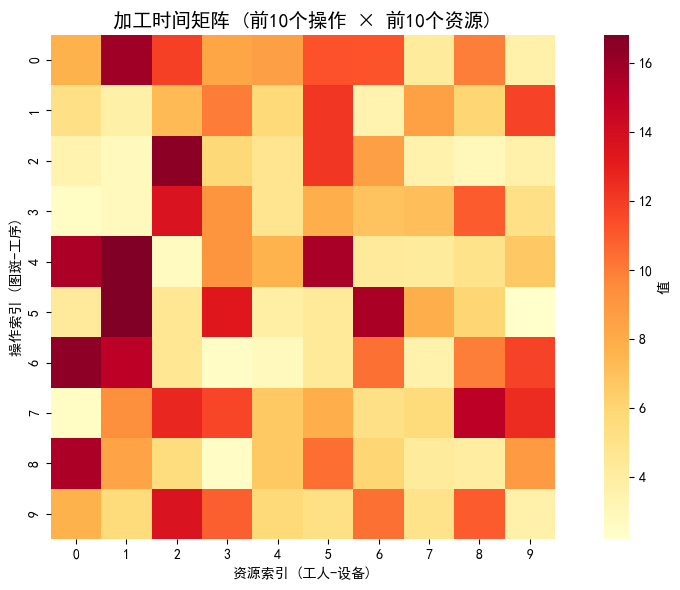

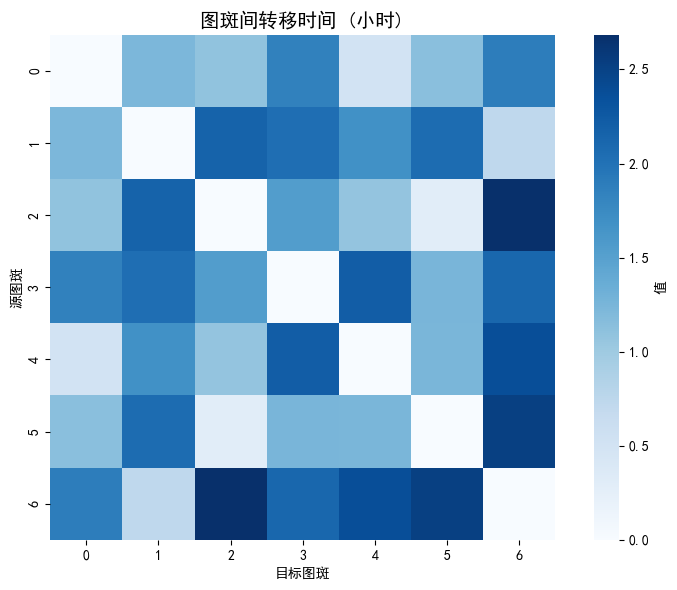

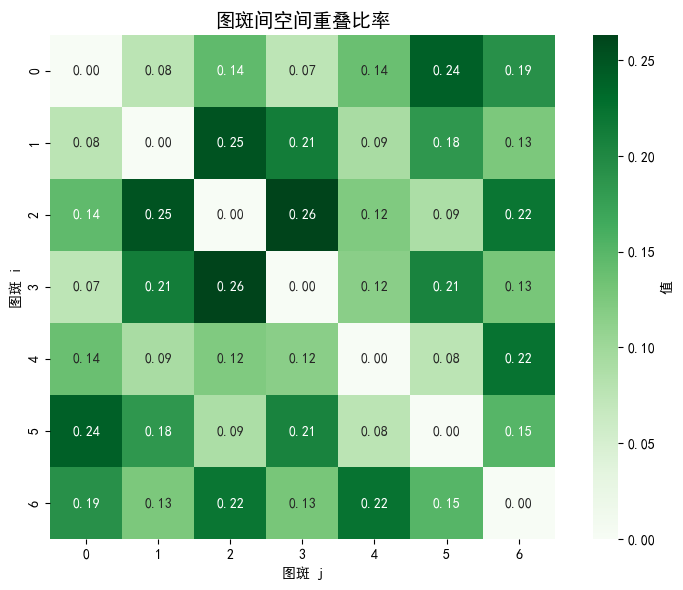

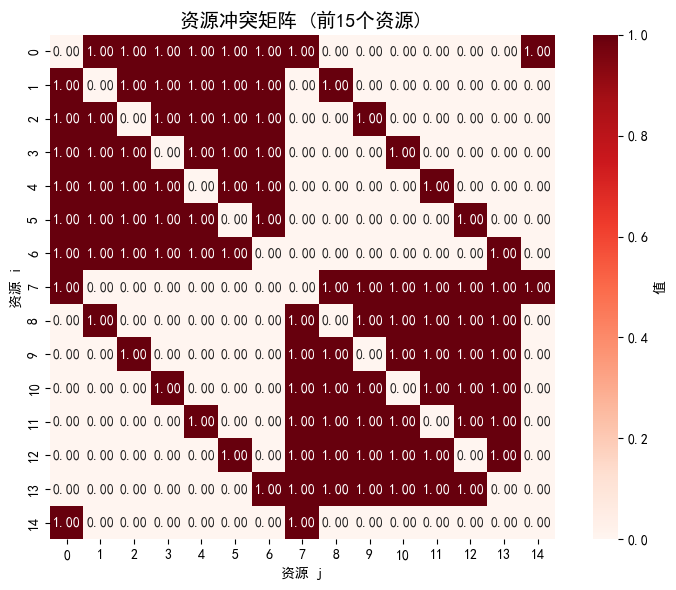

========== 遗传算法对比 ==========
运行 traditional ...
传统GA - 迭代20 | 最优工期：217.46h
传统GA - 迭代40 | 最优工期：211.87h
传统GA - 迭代60 | 最优工期：211.87h
传统GA - 迭代80 | 最优工期：211.87h
传统GA - 迭代100 | 最优工期：211.87h
传统GA - 迭代120 | 最优工期：211.87h
传统GA - 迭代140 | 最优工期：211.87h
运行 improved ...
Random test: random=0.6394267984578837, np=0.3745401188473625
改进GA - 迭代20 | 最优工期：137.12h
改进GA - 迭代40 | 最优工期：116.11h
改进GA - 迭代60 | 最优工期：112.21h
改进GA - 迭代80 | 最优工期：108.57h
改进GA - 迭代100 | 最优工期：104.32h
改进GA - 迭代120 | 最优工期：101.86h
改进GA - 迭代140 | 最优工期：99.41h


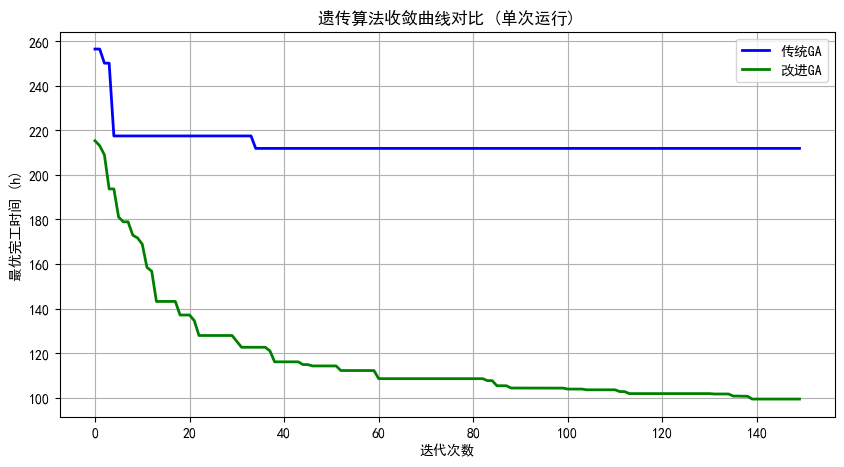

生成 传统GA 的甘特图...


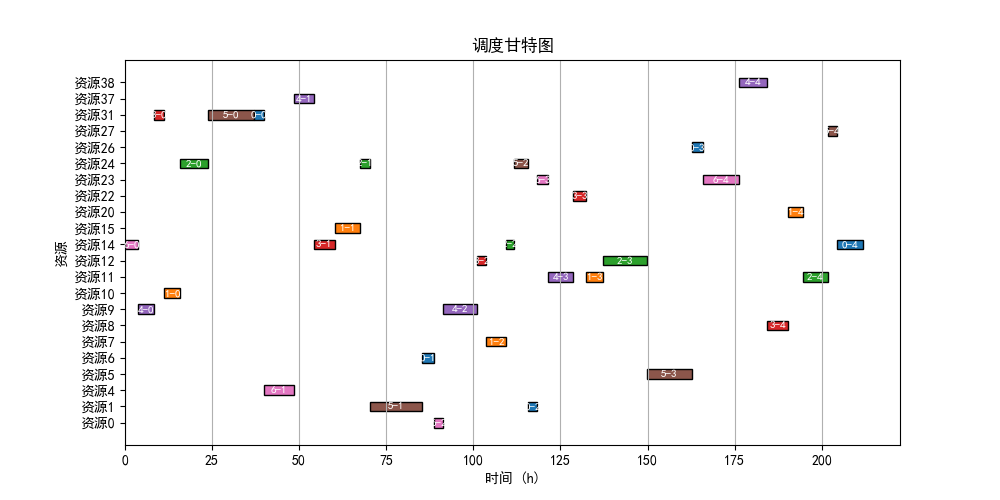

生成 改进GA 的甘特图...


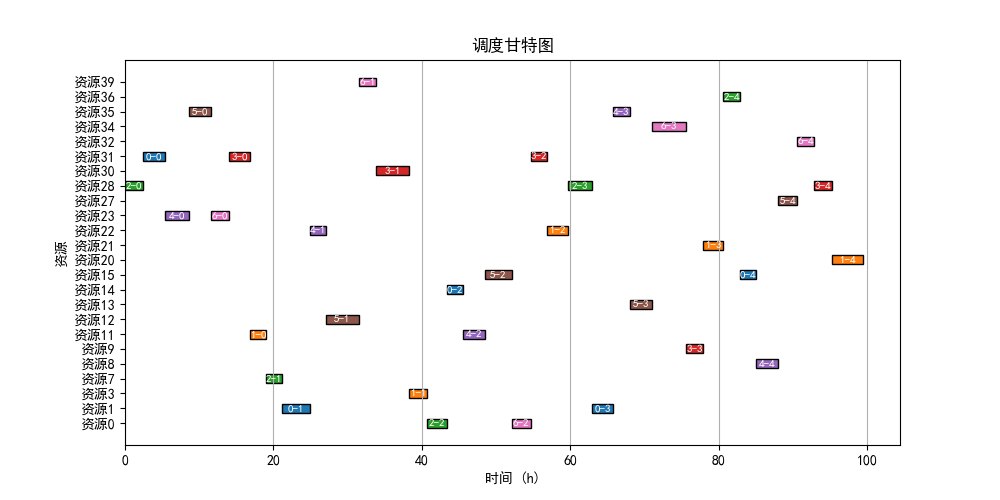


========== 模拟退火对比 ==========
运行 sa_standard ...
初始解 makespan = 230.72h
模拟退火完成，最优 makespan = 83.72h
运行 sa_adaptive ...
【自适应SA】初始解 makespan = 267.43h
  → 回火 [1/2] 温度 = 1200.0
  → 回火 [2/2] 温度 = 1200.0
【自适应SA】最终最优 = 100.65h


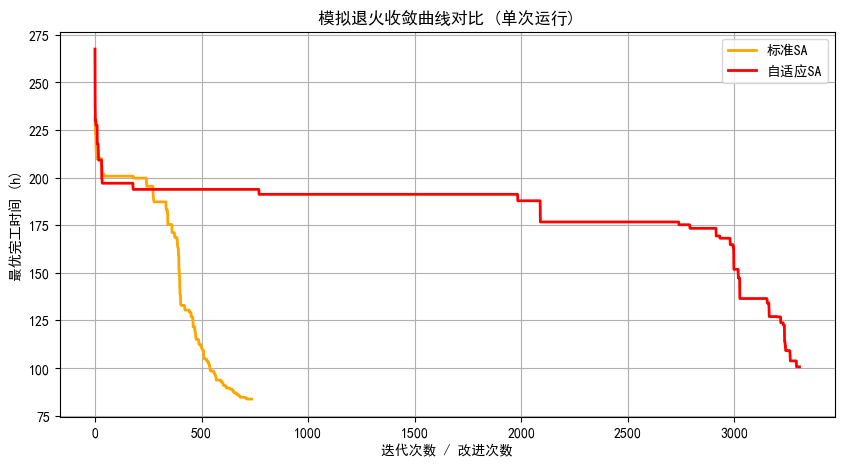

生成 标准SA 的甘特图...


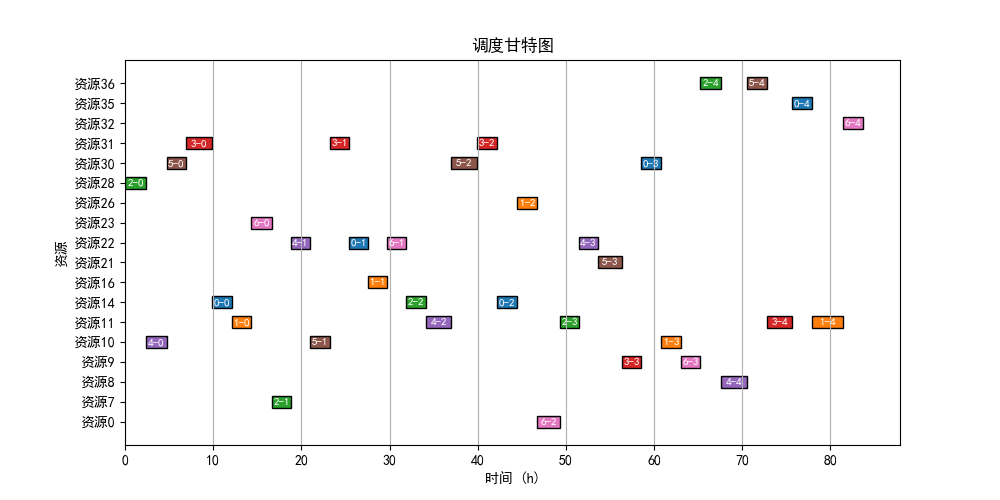

生成 自适应SA 的甘特图...


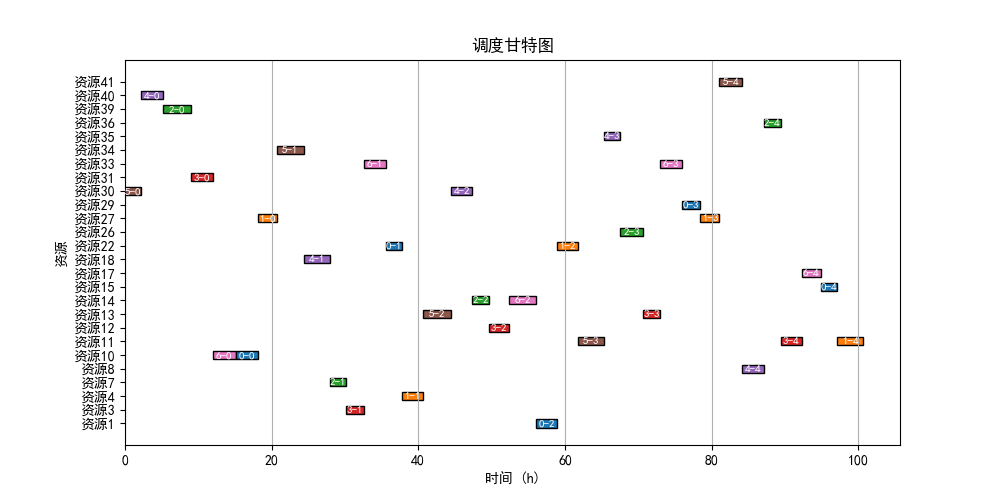

In [7]:
if __name__ == "__main__":
    config = Config()
    print(f"当前问题规模:")
    print(f"  图斑数 = {config.SPOT_NUM}")
    print(f"  每图斑工序数 = {config.PROCESS_NUM}")
    print(f"  工人数 = {config.WORKER_NUM}")
    print(f"  设备数/每人 = {config.DEVICE_NUM}")
    print(f"  资源总数 = {config.RESOURCE_NUM}")
    print(f"  总操作数 = {config.TOTAL_OPERATIONS}")

    pt, tt, ov, cm = init_data(config)   # 或 generate_matrices(config)

    # 绘制热力图（若矩阵过大，可仅绘制左上角部分）
    # 加工时间矩阵维度可能较大，只绘制前10个操作和前10个资源
    max_display_ops = min(10, pt.shape[0])
    max_display_res = min(10, pt.shape[1])
    plot_heatmap(pt[:max_display_ops, :max_display_res],
                 title=f"加工时间矩阵 (前{max_display_ops}个操作 × 前{max_display_res}个资源)",
                 xlabel="资源索引 (工人-设备)", ylabel="操作索引 (图斑-工序)",
                 figsize=(10, 6), cmap='YlOrRd')

    # 转移时间矩阵 (图斑间转移)
    plot_heatmap(tt, title="图斑间转移时间 (小时)", 
                 xlabel="目标图斑", ylabel="源图斑",
                 figsize=(8, 6), cmap='Blues')

    # 重叠比率矩阵
    plot_heatmap(ov, title="图斑间空间重叠比率", 
                 xlabel="图斑 j", ylabel="图斑 i",
                 figsize=(8, 6), cmap='Greens', annot=True)

    # 冲突矩阵 (资源冲突，二值)
    # 如果资源数太多，只显示前15×15
    max_res_display = min(15, cm.shape[0])
    plot_heatmap(cm[:max_res_display, :max_res_display],
                 title=f"资源冲突矩阵 (前{max_res_display}个资源)",
                 xlabel="资源 j", ylabel="资源 i",
                 figsize=(8, 6), cmap='Reds', annot=True)
    # 遗传算法对比
    print("========== 遗传算法对比 ==========")
    ga_results = compare_ga(n_runs=1)   # 可调整运行次数
    
    # 模拟退火对比
    print("\n========== 模拟退火对比 ==========")
    sa_results = compare_sa(n_runs=1)

========== 遗传算法对比 ==========
运行 traditional ...
传统GA - 迭代20 | 最优工期：217.46h
传统GA - 迭代40 | 最优工期：211.87h
传统GA - 迭代60 | 最优工期：211.87h
传统GA - 迭代80 | 最优工期：211.87h
传统GA - 迭代100 | 最优工期：211.87h
传统GA - 迭代120 | 最优工期：211.87h
传统GA - 迭代140 | 最优工期：211.87h
传统GA - 迭代20 | 最优工期：220.20h
传统GA - 迭代40 | 最优工期：220.20h
传统GA - 迭代60 | 最优工期：220.20h
传统GA - 迭代80 | 最优工期：214.25h
传统GA - 迭代100 | 最优工期：214.25h
传统GA - 迭代120 | 最优工期：201.38h
传统GA - 迭代140 | 最优工期：201.38h
传统GA - 迭代20 | 最优工期：231.09h
传统GA - 迭代40 | 最优工期：215.31h
传统GA - 迭代60 | 最优工期：215.31h
传统GA - 迭代80 | 最优工期：215.31h
传统GA - 迭代100 | 最优工期：215.31h
传统GA - 迭代120 | 最优工期：213.57h
传统GA - 迭代140 | 最优工期：213.53h
传统GA - 迭代20 | 最优工期：208.69h
传统GA - 迭代40 | 最优工期：208.69h
传统GA - 迭代60 | 最优工期：205.20h
传统GA - 迭代80 | 最优工期：205.20h
传统GA - 迭代100 | 最优工期：205.20h
传统GA - 迭代120 | 最优工期：205.20h
传统GA - 迭代140 | 最优工期：205.20h
传统GA - 迭代20 | 最优工期：237.03h
传统GA - 迭代40 | 最优工期：227.62h
传统GA - 迭代60 | 最优工期：227.62h
传统GA - 迭代80 | 最优工期：227.62h
传统GA - 迭代100 | 最优工期：225.52h
传统GA - 迭代120 | 最优工期：219.19h
传统GA - 迭代140 | 最优工期：

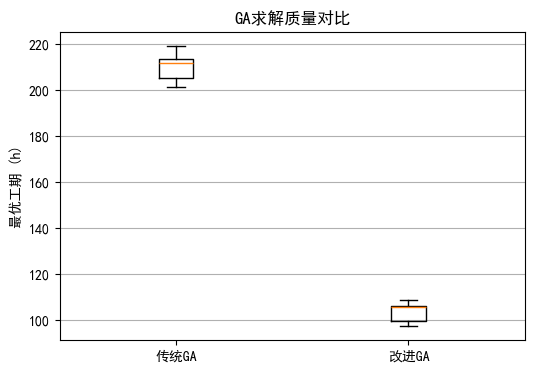

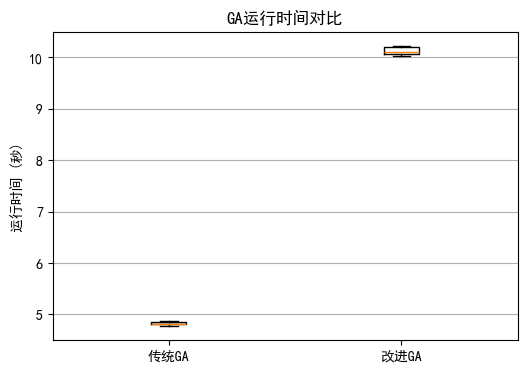


===== 遗传算法统计 (5次运行) =====
传统GA: 平均工期=210.23h, 标准差=6.29, 平均时间=4.82s, 时间标准差=0.03s
改进GA: 平均工期=103.44h, 标准差=4.30, 平均时间=10.13s, 时间标准差=0.07s

========== 模拟退火对比 ==========
运行 sa_standard ...
初始解 makespan = 230.72h
模拟退火完成，最优 makespan = 83.15h
初始解 makespan = 230.72h
模拟退火完成，最优 makespan = 83.66h
初始解 makespan = 230.72h
模拟退火完成，最优 makespan = 83.87h
初始解 makespan = 230.72h
模拟退火完成，最优 makespan = 83.30h
初始解 makespan = 230.72h
模拟退火完成，最优 makespan = 84.44h
运行 sa_adaptive ...
【自适应SA】初始解 makespan = 267.43h
  → 回火 [1/2] 温度 = 1200.0
  → 回火 [2/2] 温度 = 1200.0
【自适应SA】最终最优 = 100.65h
【自适应SA】初始解 makespan = 273.35h
  → 回火 [1/2] 温度 = 1200.0
  → 回火 [2/2] 温度 = 1200.0
【自适应SA】最终最优 = 105.32h
【自适应SA】初始解 makespan = 272.03h
  → 回火 [1/2] 温度 = 1200.0
  → 回火 [2/2] 温度 = 1200.0
【自适应SA】最终最优 = 98.88h
【自适应SA】初始解 makespan = 220.67h
  → 回火 [1/2] 温度 = 1200.0
  → 回火 [2/2] 温度 = 1200.0
【自适应SA】最终最优 = 102.26h
【自适应SA】初始解 makespan = 239.13h
  → 回火 [1/2] 温度 = 1200.0
  → 回火 [2/2] 温度 = 1200.0
【自适应SA】最终最优 = 100.73h


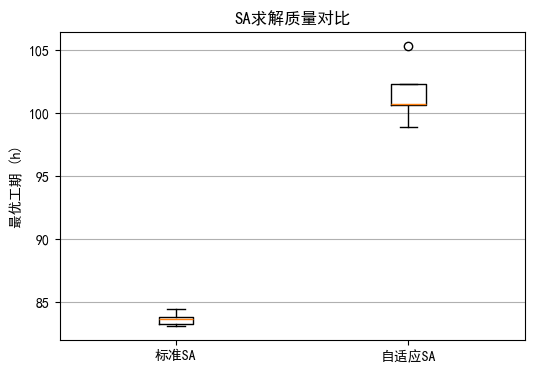

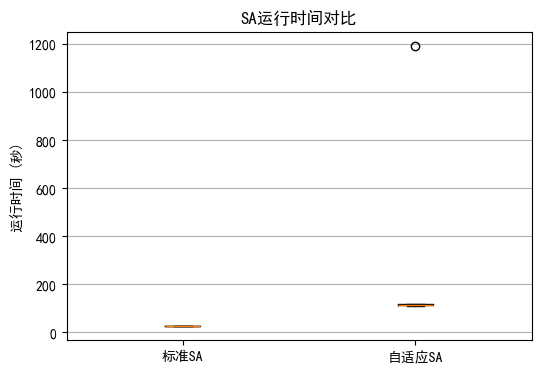


===== 模拟退火统计 (5次运行) =====
标准SA: 平均工期=83.68h, 标准差=0.46, 平均时间=27.63s, 时间标准差=0.25s
自适应SA: 平均工期=101.57h, 标准差=2.16, 平均时间=329.44s, 时间标准差=432.03s


In [8]:
    print("========== 遗传算法对比 ==========")
    ga_results = compare_ga(n_runs=5)   # 可调整运行次数
    
    # 模拟退火对比
    print("\n========== 模拟退火对比 ==========")
    sa_results = compare_sa(n_runs=5)

# 使用原来的数据

In [9]:
import random
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
import base64
import math
import time
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# ====================== 配置类 ======================
class Config:
    SPOT_NUM = 4
    PROCESS_NUM = 3
    WORKER_NUM = 2
    DEVICE_NUM = 4
    POPULATION_SIZE = 100
    MAX_ITERATIONS = 100
    CROSSOVER_RATE = 0.8
    MUTATION_RATE = 0.3
    ELITE_RATIO = 0.0
    SEED = 45
    RESOURCE_NUM = WORKER_NUM * DEVICE_NUM
    TOTAL_OPERATIONS = SPOT_NUM * PROCESS_NUM

# ====================== 数据初始化 ======================
def init_data():
    # 加工时间矩阵 (12,8)
    process_time = np.array([
    [4, 1, 8, 4, 10, 1,3, 1],   # 0: i1j1
    [17, 1,18, 16, 1, 13, 6, 19], # 1: i1j2
    [3, 3, 14, 7, 19, 10, 5, 7],   # 2: i1j3
    [17, 1, 7, 15, 13, 3, 1, 13], # 3: i2j1
    [10, 13, 7, 17, 14, 14, 18, 12],# 4: i2j2
    [18, 1, 10, 5, 10, 16, 16, 11],# 5: i2j3
    [13, 16, 19, 18,18, 9, 9, 14], # 6: i3j1  注意：原文表3-7中i3j1对应行索引6，数值需核对原文。
    [13, 8, 12, 1,7, 10, 11, 12],# 7: i3j2
    [2,11, 6, 4, 13, 5, 9, 14],  # 8: i3j3
    [4, 6, 12, 17, 16, 19, 2,2],# 9: i4j1
    [16, 16, 11, 8, 17, 11, 18, 4],# 10: i4j2
    [1, 14, 4, 15, 15, 14, 3, 17]  # 11: i4j3
    ])
    # 转移时间矩阵 (4,4)
    transfer_time = np.array([
        [0,2,4,6],
        [2,0,6,7],
        [4,6,0,4],
        [6,7,4,0]
    ])
    # 重叠比率矩阵 (4,4)
    overlap_ratio = np.array([
        [0.0,0.2,0.1,0.0],
        [0.2,0.0,0.0,0.3],
        [0.1,0.0,0.0,0.1],
        [0.0,0.3,0.1,0.0]
    ])
    # 资源冲突矩阵 (8,8)
    conflict_matrix = np.zeros((8,8), dtype=int)
    # 工人0的资源0~3互相冲突
    for i in range(4):
        for j in range(4):
            if i != j:
                conflict_matrix[i][j] = 1
    # 工人1的资源4~7互相冲突
    for i in range(4,8):
        for j in range(4,8):
            if i != j:
                conflict_matrix[i][j] = 1
    # 同一设备冲突：资源0与4（设备0）、1与5（设备1）、2与6（设备2）、3与7（设备3）
    for d in range(4):
        conflict_matrix[d][d+4] = 1
        conflict_matrix[d+4][d] = 1
    #print(conflict_matrix)
    return process_time, transfer_time, overlap_ratio, conflict_matrix


当前问题规模:
  图斑数 = 4
  每图斑工序数 = 3
  工人数 = 2
  设备数/每人 = 4
  资源总数 = 8
  总操作数 = 12


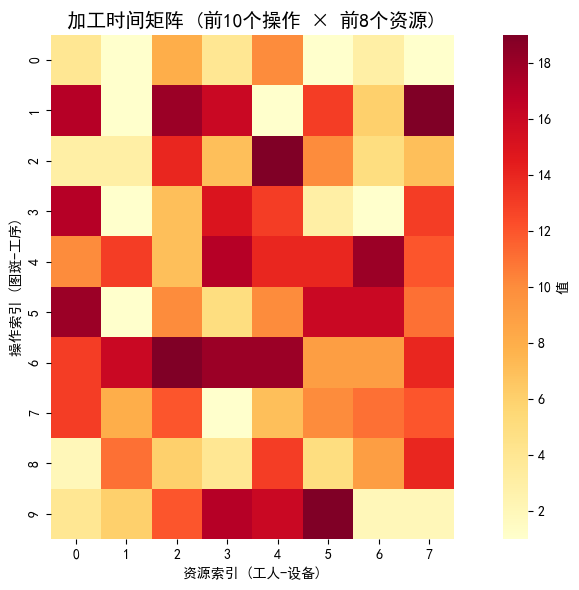

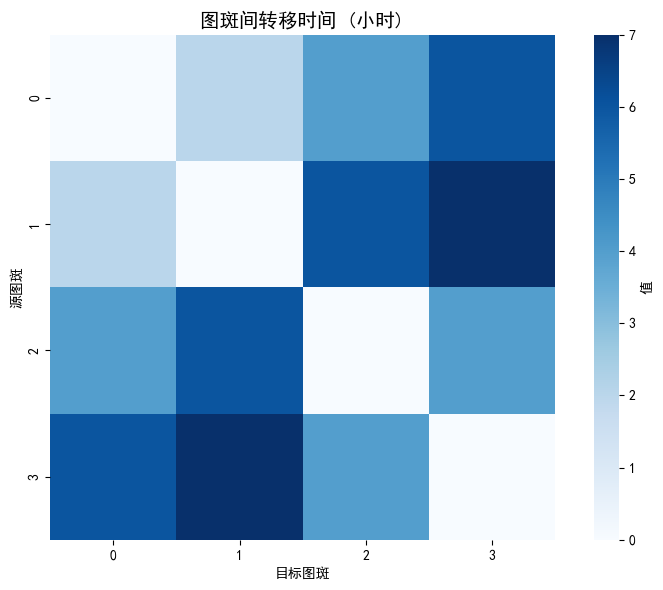

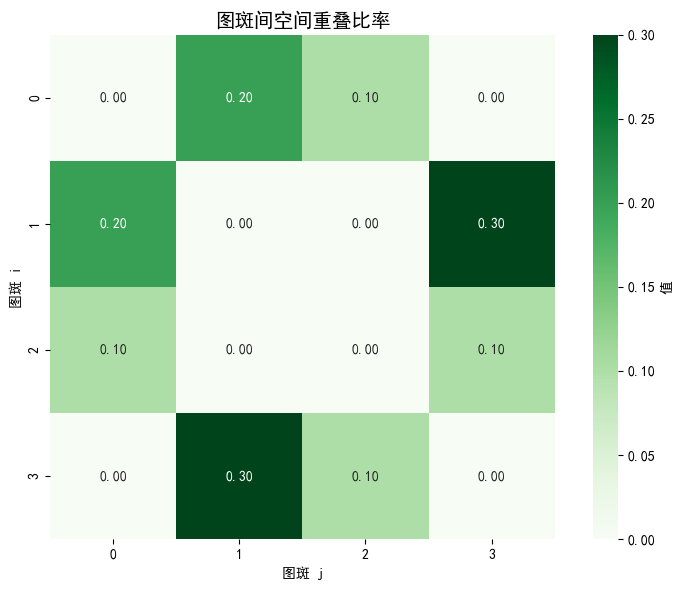

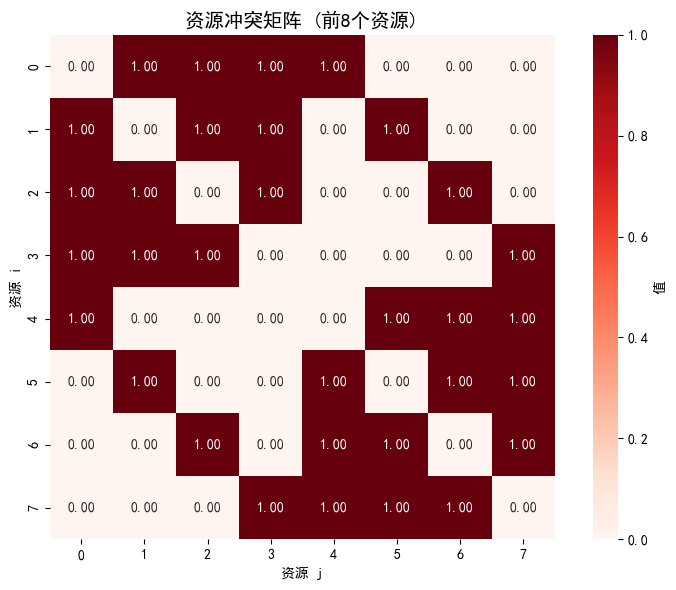

========== 遗传算法对比 ==========
运行 traditional ...
传统GA - 迭代20 | 最优工期：60.00h
传统GA - 迭代40 | 最优工期：46.00h
传统GA - 迭代60 | 最优工期：41.00h
传统GA - 迭代80 | 最优工期：41.00h
传统GA - 迭代100 | 最优工期：41.00h
传统GA - 迭代120 | 最优工期：41.00h
传统GA - 迭代140 | 最优工期：41.00h
运行 improved ...
Random test: random=0.6394267984578837, np=0.3745401188473625
改进GA - 迭代20 | 最优工期：33.00h
改进GA - 迭代40 | 最优工期：33.00h
改进GA - 迭代60 | 最优工期：33.00h
改进GA - 迭代80 | 最优工期：33.00h
改进GA - 迭代100 | 最优工期：33.00h
改进GA - 迭代120 | 最优工期：33.00h
改进GA - 迭代140 | 最优工期：33.00h


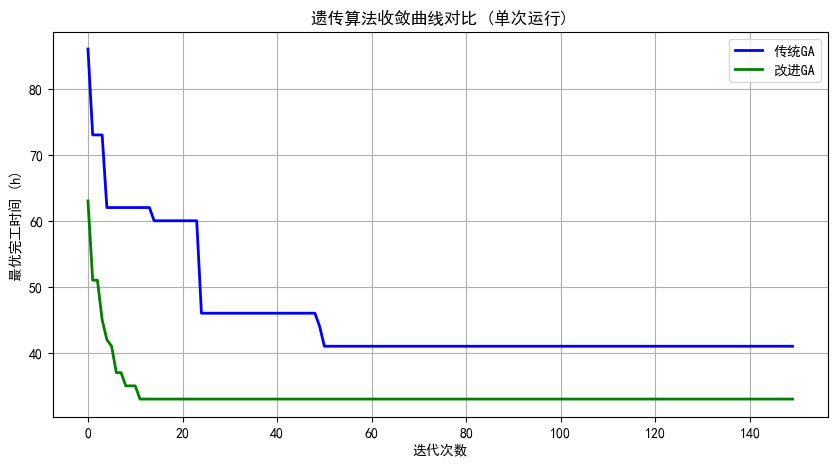

生成 传统GA 的甘特图...


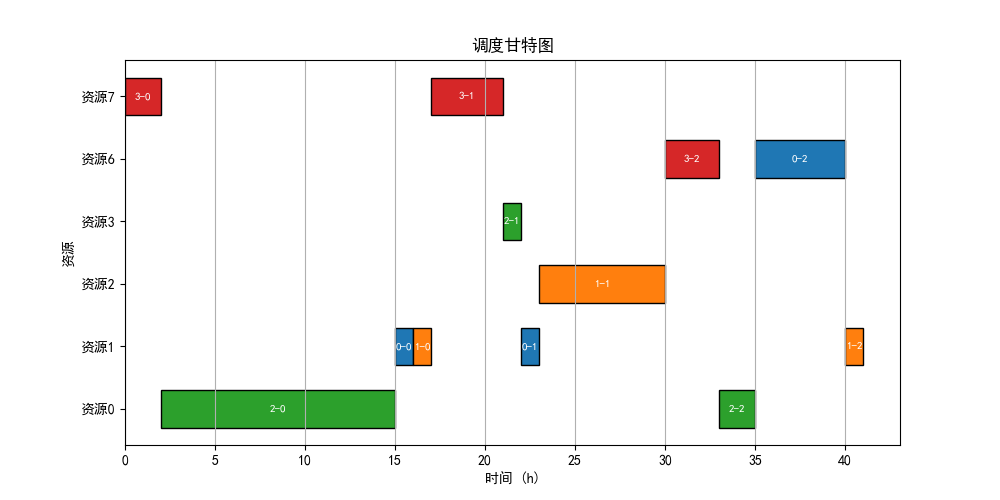

生成 改进GA 的甘特图...


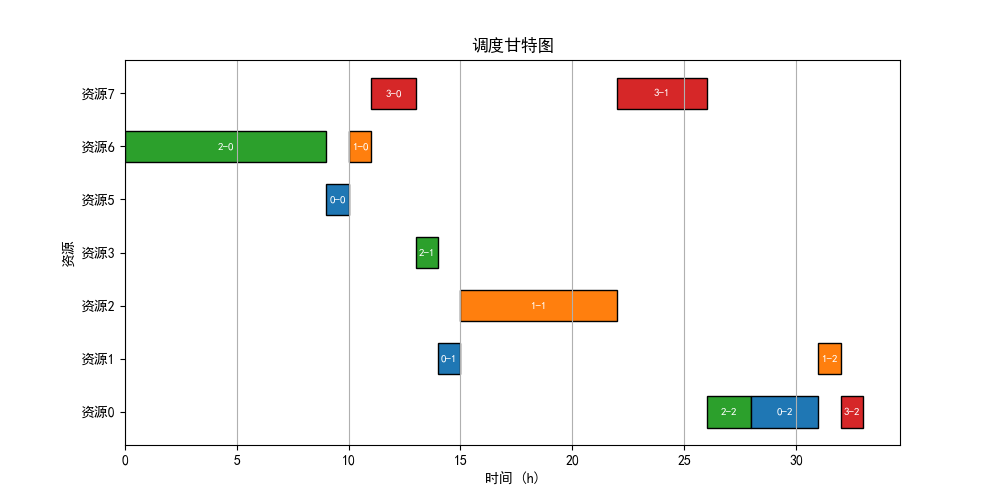


========== 模拟退火对比 ==========
运行 sa_standard ...
初始解 makespan = 75.00h
模拟退火完成，最优 makespan = 33.00h
运行 sa_adaptive ...
【自适应SA】初始解 makespan = 114.00h
  → 回火 [1/2] 温度 = 1200.0
  → 回火 [2/2] 温度 = 1200.0
【自适应SA】最终最优 = 33.00h


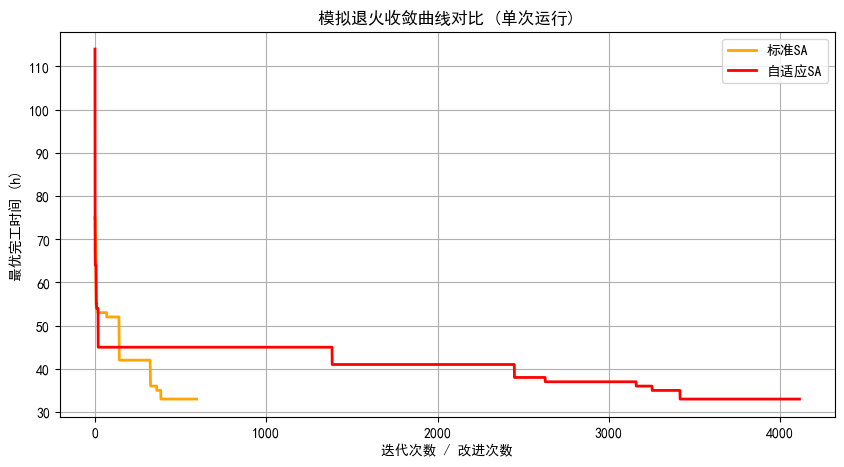

生成 标准SA 的甘特图...


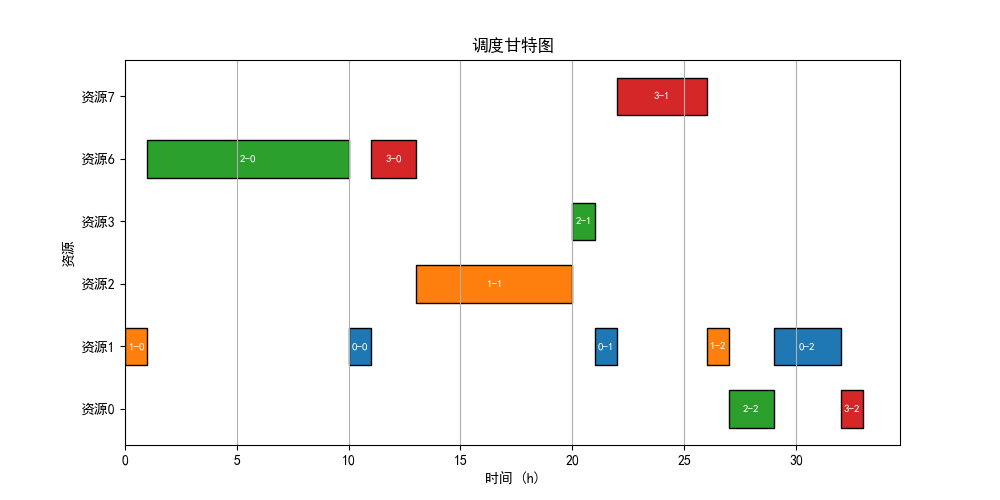

生成 自适应SA 的甘特图...


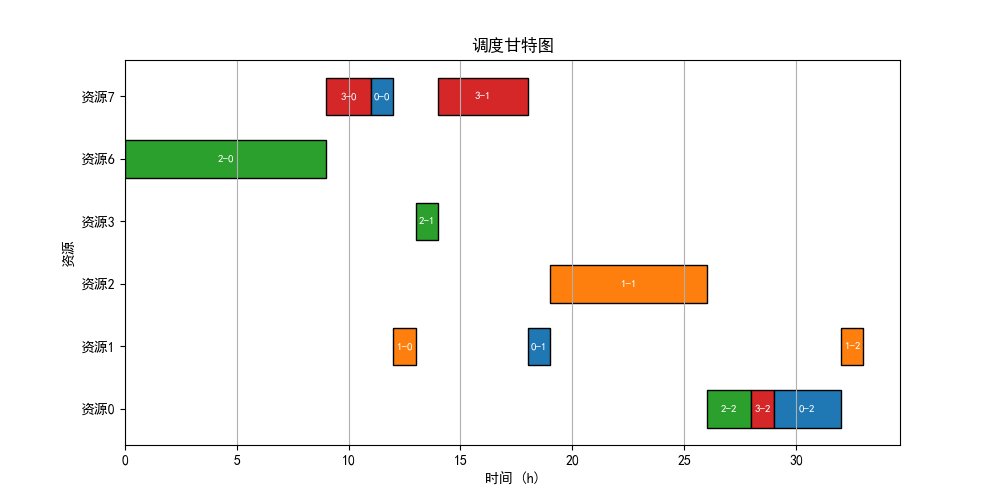

In [10]:
if __name__ == "__main__":
    config = Config()
    print(f"当前问题规模:")
    print(f"  图斑数 = {config.SPOT_NUM}")
    print(f"  每图斑工序数 = {config.PROCESS_NUM}")
    print(f"  工人数 = {config.WORKER_NUM}")
    print(f"  设备数/每人 = {config.DEVICE_NUM}")
    print(f"  资源总数 = {config.RESOURCE_NUM}")
    print(f"  总操作数 = {config.TOTAL_OPERATIONS}")

    pt, tt, ov, cm = init_data()   # 或 generate_matrices(config)

    # 绘制热力图（若矩阵过大，可仅绘制左上角部分）
    # 加工时间矩阵维度可能较大，只绘制前10个操作和前10个资源
    max_display_ops = min(10, pt.shape[0])
    max_display_res = min(10, pt.shape[1])
    plot_heatmap(pt[:max_display_ops, :max_display_res],
                 title=f"加工时间矩阵 (前{max_display_ops}个操作 × 前{max_display_res}个资源)",
                 xlabel="资源索引 (工人-设备)", ylabel="操作索引 (图斑-工序)",
                 figsize=(10, 6), cmap='YlOrRd')

    # 转移时间矩阵 (图斑间转移)
    plot_heatmap(tt, title="图斑间转移时间 (小时)", 
                 xlabel="目标图斑", ylabel="源图斑",
                 figsize=(8, 6), cmap='Blues')

    # 重叠比率矩阵
    plot_heatmap(ov, title="图斑间空间重叠比率", 
                 xlabel="图斑 j", ylabel="图斑 i",
                 figsize=(8, 6), cmap='Greens', annot=True)

    # 冲突矩阵 (资源冲突，二值)
    # 如果资源数太多，只显示前15×15
    max_res_display = min(15, cm.shape[0])
    plot_heatmap(cm[:max_res_display, :max_res_display],
                 title=f"资源冲突矩阵 (前{max_res_display}个资源)",
                 xlabel="资源 j", ylabel="资源 i",
                 figsize=(8, 6), cmap='Reds', annot=True)
    # 遗传算法对比
    print("========== 遗传算法对比 ==========")
    ga_results = compare_ga(n_runs=1)   # 可调整运行次数
    
    # 模拟退火对比
    print("\n========== 模拟退火对比 ==========")
    sa_results = compare_sa(n_runs=1)

========== 遗传算法对比 ==========
运行 traditional ...
传统GA - 迭代20 | 最优工期：60.00h
传统GA - 迭代40 | 最优工期：46.00h
传统GA - 迭代60 | 最优工期：41.00h
传统GA - 迭代80 | 最优工期：41.00h
传统GA - 迭代100 | 最优工期：41.00h
传统GA - 迭代120 | 最优工期：41.00h
传统GA - 迭代140 | 最优工期：41.00h
传统GA - 迭代20 | 最优工期：52.00h
传统GA - 迭代40 | 最优工期：52.00h
传统GA - 迭代60 | 最优工期：49.00h
传统GA - 迭代80 | 最优工期：49.00h
传统GA - 迭代100 | 最优工期：49.00h
传统GA - 迭代120 | 最优工期：44.00h
传统GA - 迭代140 | 最优工期：44.00h
传统GA - 迭代20 | 最优工期：60.00h
传统GA - 迭代40 | 最优工期：37.00h
传统GA - 迭代60 | 最优工期：37.00h
传统GA - 迭代80 | 最优工期：35.00h
传统GA - 迭代100 | 最优工期：35.00h
传统GA - 迭代120 | 最优工期：35.00h
传统GA - 迭代140 | 最优工期：35.00h
传统GA - 迭代20 | 最优工期：47.00h
传统GA - 迭代40 | 最优工期：40.00h
传统GA - 迭代60 | 最优工期：40.00h
传统GA - 迭代80 | 最优工期：40.00h
传统GA - 迭代100 | 最优工期：40.00h
传统GA - 迭代120 | 最优工期：39.00h
传统GA - 迭代140 | 最优工期：39.00h
传统GA - 迭代20 | 最优工期：50.00h
传统GA - 迭代40 | 最优工期：50.00h
传统GA - 迭代60 | 最优工期：49.00h
传统GA - 迭代80 | 最优工期：46.00h
传统GA - 迭代100 | 最优工期：39.00h
传统GA - 迭代120 | 最优工期：39.00h
传统GA - 迭代140 | 最优工期：39.00h
传统GA - 迭代20 | 最优工期：52.00h
传

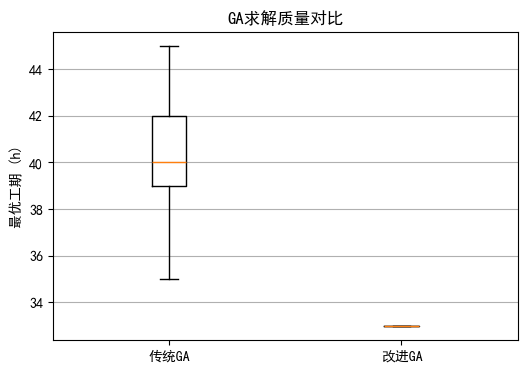

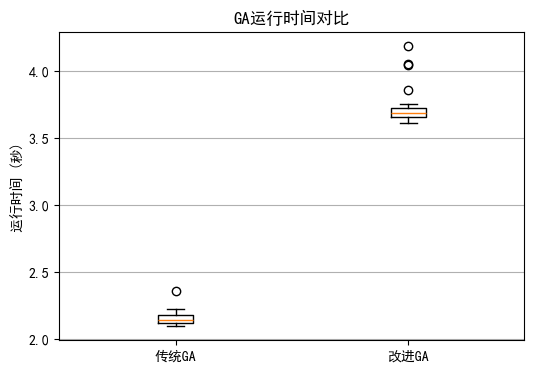


===== 遗传算法统计 (20次运行) =====
传统GA: 平均工期=40.35h, 标准差=2.73, 平均时间=2.16s, 时间标准差=0.06s
改进GA: 平均工期=33.00h, 标准差=0.00, 平均时间=3.75s, 时间标准差=0.16s

========== 模拟退火对比 ==========
运行 sa_standard ...
初始解 makespan = 112.00h
模拟退火完成，最优 makespan = 33.00h
初始解 makespan = 108.00h
模拟退火完成，最优 makespan = 33.00h
初始解 makespan = 85.00h
模拟退火完成，最优 makespan = 33.00h
初始解 makespan = 93.00h
模拟退火完成，最优 makespan = 33.00h
初始解 makespan = 64.00h
模拟退火完成，最优 makespan = 33.00h
初始解 makespan = 86.00h
模拟退火完成，最优 makespan = 33.00h
初始解 makespan = 80.00h
模拟退火完成，最优 makespan = 33.00h
初始解 makespan = 91.00h
模拟退火完成，最优 makespan = 33.00h
初始解 makespan = 95.00h
模拟退火完成，最优 makespan = 33.00h
初始解 makespan = 102.00h
模拟退火完成，最优 makespan = 33.00h
初始解 makespan = 90.00h
模拟退火完成，最优 makespan = 33.00h
初始解 makespan = 93.00h
模拟退火完成，最优 makespan = 33.00h
初始解 makespan = 96.00h
模拟退火完成，最优 makespan = 33.00h
初始解 makespan = 87.00h
模拟退火完成，最优 makespan = 33.00h
初始解 makespan = 78.00h
模拟退火完成，最优 makespan = 33.00h
初始解 makespan = 127.00h
模拟退火完成，最优 makespan = 33.00h
初始解 makespan 

In [ ]:
    print("========== 遗传算法对比 ==========")
    ga_results = compare_ga(n_runs=20)   # 可调整运行次数
    
    # 模拟退火对比
    print("\n========== 模拟退火对比 ==========")
    sa_results = compare_sa(n_runs=20)